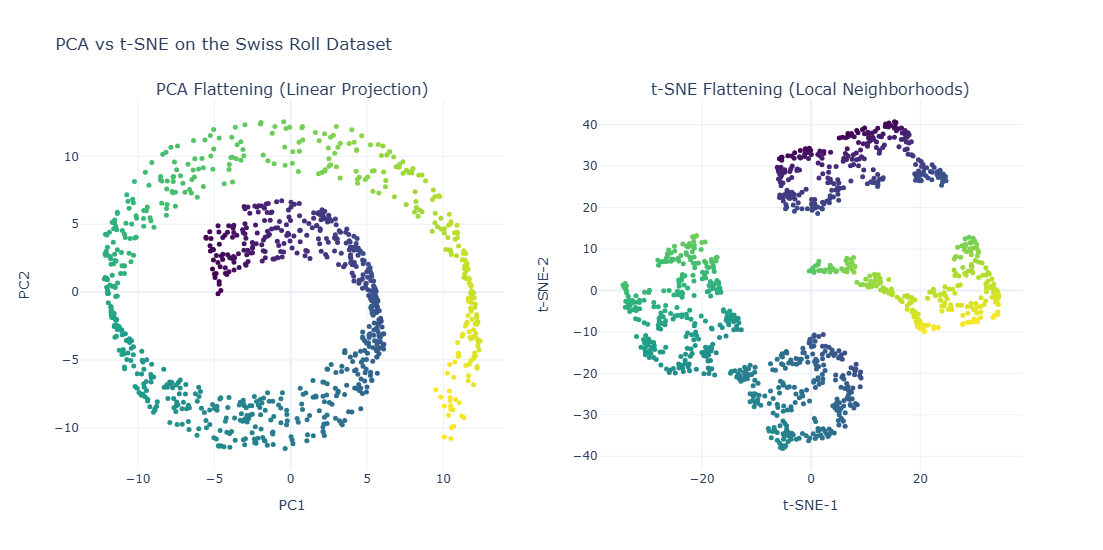

In [14]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ---- 1. Generate Swiss roll data ----
X, color = make_swiss_roll(n_samples=1000, noise=0.05, random_state=2)
X = X - X.mean(axis=0, keepdims=True)  # center for aesthetics

# ---- 2. PCA to 2D ----
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

# ---- 3. t-SNE to 2D ----
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=2,
)
X_tsne = tsne_2d.fit_transform(X)

# ---- 4. Side-by-side subplots ----
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("PCA Flattening (Linear Projection)",
                    "t-SNE Flattening (Local Neighborhoods)"),
    horizontal_spacing=0.1
)

# Left: PCA
fig.add_trace(
    go.Scatter(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        mode="markers",
        marker=dict(size=5, color=color, colorscale="Viridis"),
        name="PCA"
    ),
    row=1, col=1
)

# Right: t-SNE
fig.add_trace(
    go.Scatter(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        mode="markers",
        marker=dict(size=5, color=color, colorscale="Viridis"),
        name="t-SNE"
    ),
    row=1, col=2
)

# ---- 5. Layout & axis labels ----
fig.update_layout(
    title_text="PCA vs t-SNE on the Swiss Roll Dataset",
    template="plotly_white",
    width=1100,
    height=550,
    showlegend=False,
)

fig.update_xaxes(title_text="PC1", row=1, col=1)
fig.update_yaxes(title_text="PC2", row=1, col=1)

fig.update_xaxes(title_text="t-SNE-1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE-2", row=1, col=2)

fig.show()


---